<a href="https://colab.research.google.com/github/lingRowan/Cancer-Diagnosis/blob/main/Build_a_Generative_Adversarial_Network_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning with PyTorch : Build a Generative Adversarial Network

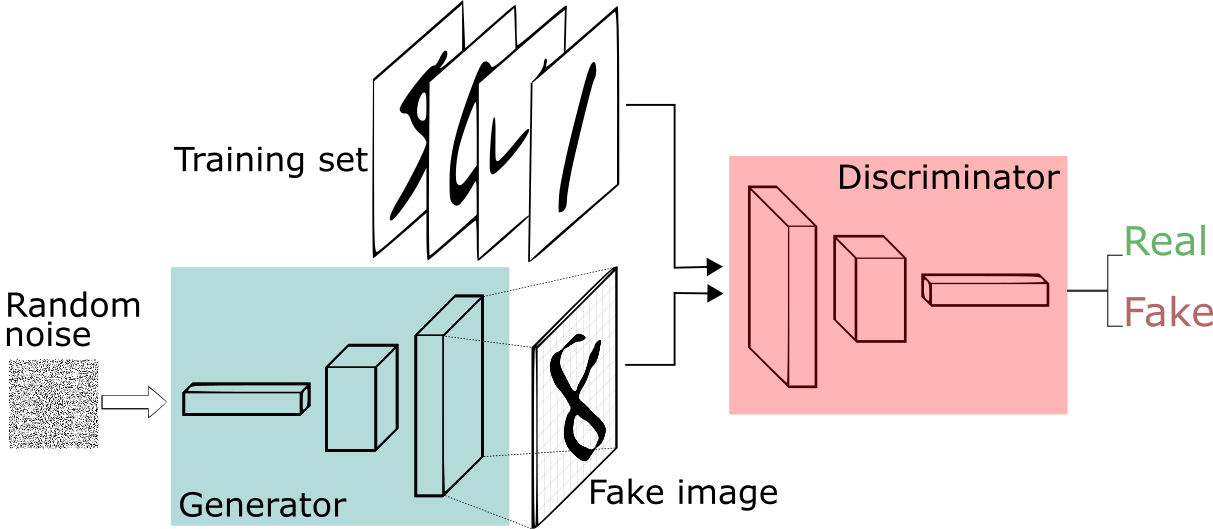

In [ ]:
import torch
torch.manual_seed(42)
import numpy as np
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

# Configurations

In [ ]:
device = 'cpu'
batch_size = 128
noise_dim = 64

#optimizer parameters
lr = 0.002
beta = (0.5, 0.99)


#training variables
epochs = 20

# Load MNIST Dataset

In [ ]:
from torchvision import datasets, transforms as T


In [ ]:
train_augs = T.Compose([T.RandomRotation((-20, +20)),
T.ToTensor()])

In [ ]:
trainset = datasets.MNIST('MNIST/', download = True, train = True, transform = train_augs )

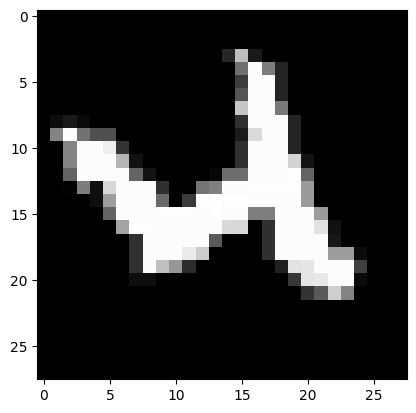

In [ ]:
image, label = trainset[20]

plt.imshow(image.squeeze(), cmap = 'gray')

# Load Dataset Into Batches

In [ ]:
from torch.utils.data import DataLoader
from torchvision.utils import make_grid

In [ ]:
trainloader = DataLoader(trainset, batch_size = batch_size, shuffle = True)

In [ ]:
dataiter = iter(trainloader)
images, _ = next(dataiter)

In [ ]:
# 'show_tensor_images' : function is used to plot some of images from the batch

def show_tensor_images(tensor_img, num_images = 16, size=(1, 28, 28)):
    unflat_img = tensor_img.detach().cpu()
    img_grid = make_grid(unflat_img[:num_images], nrow=4)
    plt.imshow(img_grid.permute(1, 2, 0).squeeze())
    plt.show()

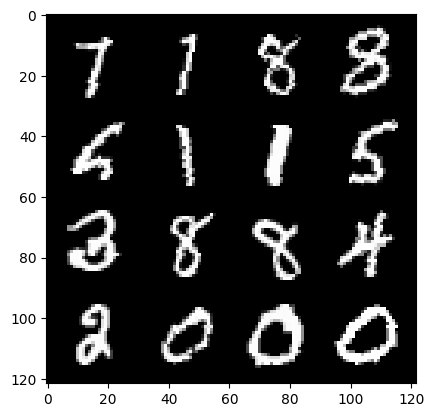

In [ ]:
show_tensor_images(images,num_images= 16)

# Create Discriminator Network

In [ ]:
#In case if torch summary is not installed

!pip install torchsummary

In [ ]:
from torch import nn
from torchsummary import summary

In [ ]:
'''

Network : Discriminator

input : (bs, 1, 28, 28)
      |                                                                                               ---- SUMMARY ----
      V
Conv2d( in_channels = 1, out_channels = 16, kernel_size = (3,3), stride = 2)                           #(bs, 16, 13, 13)
BatchNorm2d()                                                                                          #(bs, 16, 13, 13)
LeakyReLU()                                                                                            #(bs, 16, 13, 13)
      |
      V
Conv2d( in_channels = 16, out_channels = 32, kernel_size = (5,5), stride = 2)                          #(bs, 32, 5, 5)
BatchNorm2d()                                                                                          #(bs, 32, 5, 5)
LeakyReLU()                                                                                            #(bs, 32, 5, 5)
      |
      V
Conv2d( in_channels = 32, out_channels = 64, kernel_size = (5,5), stride = 2)                          #(bs, 64, 1, 1)
BatchNorm2d()                                                                                          #(bs, 64, 1, 1)
LeakyReLU()                                                                                            #(bs, 64, 1, 1)
      |
      V
Flatten()                                                                                              #(bs, 64)
Linear(in_features = 64, out_features = 1)                                                             #(bs, 1)

'''

'\n\nNetwork : Discriminator\n\ninput : (bs, 1, 28, 28)\n      |                                                                                               ---- SUMMARY ----\n      V\nConv2d( in_channels = 1, out_channels = 16, kernel_size = (3,3), stride = 2)                           #(bs, 16, 13, 13)\nBatchNorm2d()                                                                                          #(bs, 16, 13, 13)\nLeakyReLU()                                                                                            #(bs, 16, 13, 13)\n      |\n      V\nConv2d( in_channels = 16, out_channels = 32, kernel_size = (5,5), stride = 2)                          #(bs, 32, 5, 5)\nBatchNorm2d()                                                                                          #(bs, 32, 5, 5)\nLeakyReLU()                                                                                            #(bs, 32, 5, 5)\n      |\n      V\nConv2d( in_channels = 32, out_channels = 64, kernel

In [ ]:
def get_disc_block(in_channels, out_channels, kernel_size, stride):
    return(nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride),
        nn.BatchNorm2d(out_channels),
        nn.LeakyReLU(0.2)))



In [ ]:
class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator,self).__init__()
    self.block1 = get_disc_block(1,16,(3,3),2)
    self.block2 = get_disc_block(16,32,(5,5),2)
    self.block3 = get_disc_block(32,64,(5,5),2)

    self.flatten = nn.Flatten()
    self.linear = nn.Linear(64, 1)

  def forward(self, images):
    x1 = self.block1(images)
    x2 = self.block2(x1)
    x3 = self.block3(x2)
    x4 = self.flatten(x3)
    x5 = self.linear(x4)

    return x5

In [ ]:
D = Discriminator()
D.to(device)
summary(D,input_size = (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 13, 13]             160
       BatchNorm2d-2           [-1, 16, 13, 13]              32
         LeakyReLU-3           [-1, 16, 13, 13]               0
            Conv2d-4             [-1, 32, 5, 5]          12,832
       BatchNorm2d-5             [-1, 32, 5, 5]              64
         LeakyReLU-6             [-1, 32, 5, 5]               0
            Conv2d-7             [-1, 64, 1, 1]          51,264
       BatchNorm2d-8             [-1, 64, 1, 1]             128
         LeakyReLU-9             [-1, 64, 1, 1]               0
          Flatten-10                   [-1, 64]               0
           Linear-11                    [-1, 1]              65
Total params: 64,545
Trainable params: 64,545
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/ba

# Create Generator Network

In [ ]:
'''

Network : Generator

z_dim = 64
input : (bs,z_dim)

      |
      | Reshape
      V

input : (bs, channel, height, width) -> (bs, z_dim , 1 , 1)
      |                                                                                               ---- SUMMARY ----
      V
ConvTranspose2d( in_channels = z_dim, out_channels = 256, kernel_size = (3,3), stride = 2)             #(bs, 256, 3, 3)
BatchNorm2d()                                                                                          #(bs, 256, 3, 3)
ReLU()                                                                                                 #(bs, 256, 3, 3)
      |
      V
ConvTranspose2d( in_channels = 256, out_channels = 128, kernel_size = (4,4), stride = 1)               #(bs, 128, 6, 6)
BatchNorm2d()                                                                                          #(bs, 128, 6, 6)
ReLU()                                                                                                 #(bs, 128, 6, 6)
      |
      V
ConvTranspose2d( in_channels = 128, out_channels = 64, kernel_size = (3,3), stride = 2)                #(bs, 64, 13, 13)
BatchNorm2d()                                                                                          #(bs, 64, 13, 13)
ReLU()                                                                                                 #(bs, 64, 13, 13)
      |
      V
ConvTranspose2d( in_channels = 64, out_channels = 1, kernel_size = (4,4), stride = 2)                  #(bs, 1, 28, 28)
Tanh()                                                                                                 #(bs, 1, 28, 28)

'''

'\n\nNetwork : Generator\n\nz_dim = 64\ninput : (bs,z_dim)\n\n      |\n      | Reshape\n      V\n\ninput : (bs, channel, height, width) -> (bs, z_dim , 1 , 1)\n      |                                                                                               ---- SUMMARY ----\n      V\nConvTranspose2d( in_channels = z_dim, out_channels = 256, kernel_size = (3,3), stride = 2)             #(bs, 256, 3, 3)\nBatchNorm2d()                                                                                          #(bs, 256, 3, 3)\nReLU()                                                                                                 #(bs, 256, 3, 3)\n      |\n      V\nConvTranspose2d( in_channels = 256, out_channels = 128, kernel_size = (4,4), stride = 1)               #(bs, 128, 6, 6)\nBatchNorm2d()                                                                                          #(bs, 128, 6, 6)\nReLU()                                                                                 

In [ ]:
def get_gen_block(in_channels, out_channels, kernel_size, stride, final_block = False):
  if final_block == True:
    return nn.Sequential(
        nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride),
        nn.Tanh()
    )
  return nn.Sequential(
      nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride),
      nn.BatchNorm2d(out_channels),
      nn.ReLU()
  )

In [ ]:
class Generator(nn.Module):
  def __init__(self, noise_dim):
    super(Generator, self).__init__() # Corrected line
    self.noise_dim = noise_dim
    self.block1 = get_gen_block(noise_dim, 256, (3,3), 2)
    self.block2 = get_gen_block(256,128,(4,4), 1)
    self.blocks3 = get_gen_block(128,64,(3,3), 2)
    self.block4 = get_gen_block(64, 1, (4,4), 2,final_block = True)

  def forward(self, r_noise_vector):
    x = r_noise_vector.view(-1, self.noise_dim, 1, 1)
    x1 = self.block1(x)
    x2 = self.block2(x1)
    x3 = self.blocks3(x2) # Corrected typo from blocks3 to block3. Changed from self.blocks3 to self.blocks3
    x4 = self.block4(x3)
    return x4

In [ ]:
G = Generator(noise_dim)
G.to(device)
summary(G, input_size = (1, noise_dim))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   ConvTranspose2d-1            [-1, 256, 3, 3]         147,712
       BatchNorm2d-2            [-1, 256, 3, 3]             512
              ReLU-3            [-1, 256, 3, 3]               0
   ConvTranspose2d-4            [-1, 128, 6, 6]         524,416
       BatchNorm2d-5            [-1, 128, 6, 6]             256
              ReLU-6            [-1, 128, 6, 6]               0
   ConvTranspose2d-7           [-1, 64, 13, 13]          73,792
       BatchNorm2d-8           [-1, 64, 13, 13]             128
              ReLU-9           [-1, 64, 13, 13]               0
  ConvTranspose2d-10            [-1, 1, 28, 28]           1,025
             Tanh-11            [-1, 1, 28, 28]               0
Total params: 747,841
Trainable params: 747,841
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/

In [ ]:
# Replace Random initialized weights to Normal weights

def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 0.0, 0.02)
        nn.init.constant_(m.bias, 0)

In [ ]:
D = D.apply(weights_init)
G = G.apply(weights_init)

# Create Loss Function and Load Optimizer

In [ ]:
def real_loss(disc_prediction):
  criterion = nn.BCEWithLogitsLoss()
  ground_truth = torch.ones_like(disc_prediction)
  loss = criterion(disc_prediction, ground_truth)
  return loss

def fake_loss(disc_prediction):
  criterion = nn.BCEWithLogitsLoss()
  ground_truth = torch.zeros_like(disc_prediction)
  loss = criterion(disc_prediction, ground_truth)
  return loss

In [ ]:
D_opt = torch.optim.Adam(D.parameters(), lr = lr, betas = beta)
G_opt = torch.optim.Adam(G.parameters(), lr = lr, betas = beta)

# Training Loop

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :1, D_loss : 0.6734, G_loss : 0.7391


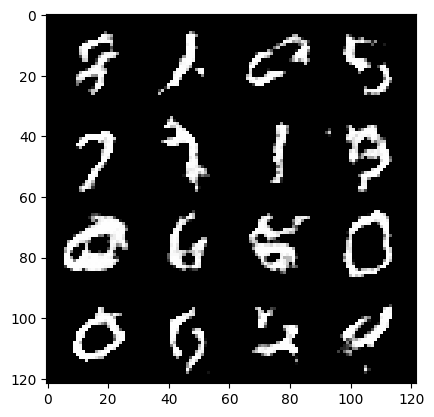

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :2, D_loss : 0.6296, G_loss : 0.8520


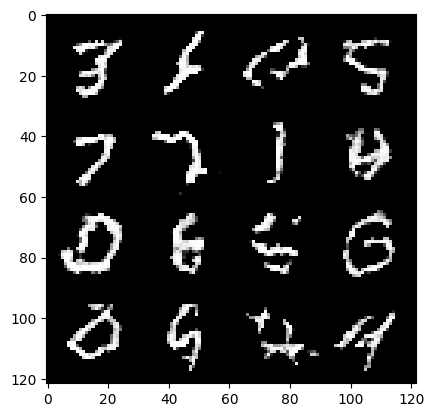

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :3, D_loss : 0.6269, G_loss : 0.8899


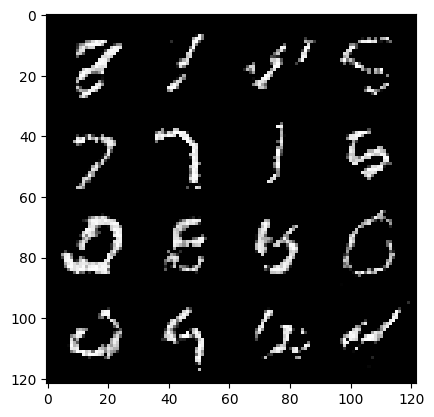

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :4, D_loss : 0.6345, G_loss : 0.8854


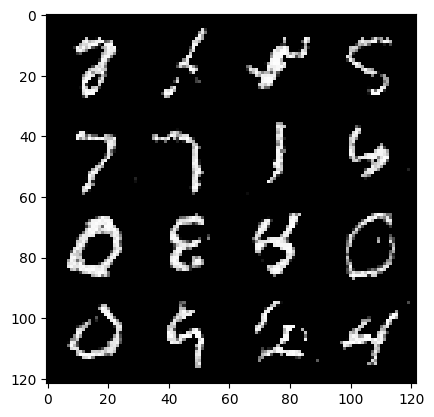

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :5, D_loss : 0.6412, G_loss : 0.8779


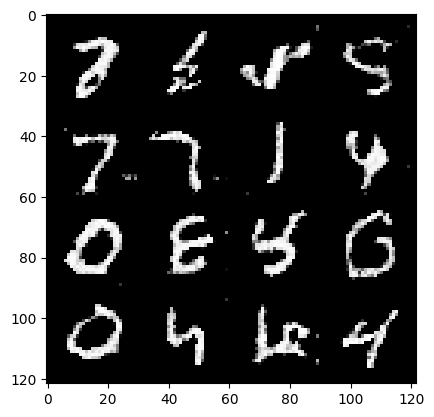

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :6, D_loss : 0.6478, G_loss : 0.8594


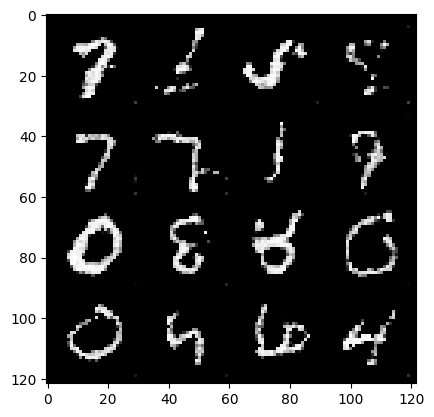

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :7, D_loss : 0.6442, G_loss : 0.8600


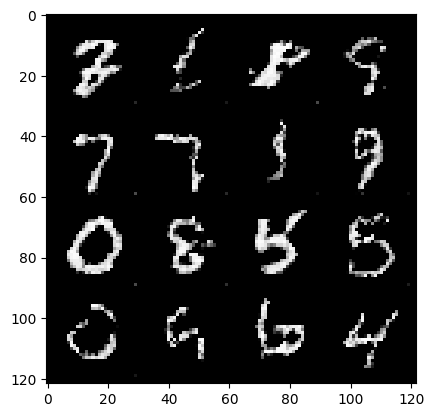

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :8, D_loss : 0.6403, G_loss : 0.8676


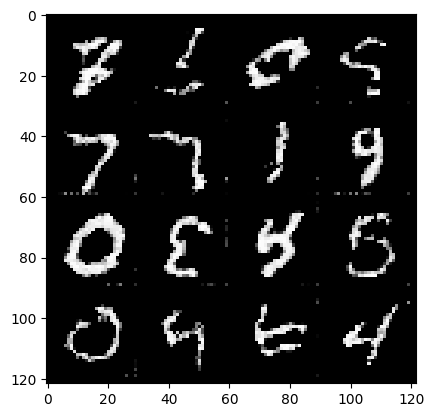

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :9, D_loss : 0.6315, G_loss : 0.8889


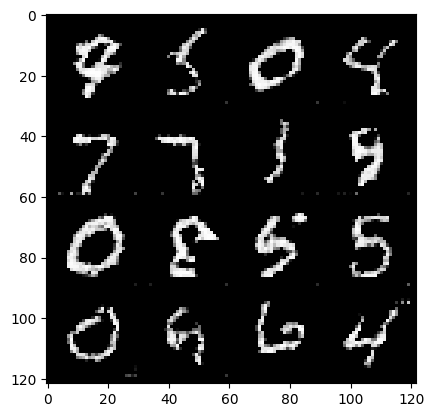

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :10, D_loss : 0.6259, G_loss : 0.9060


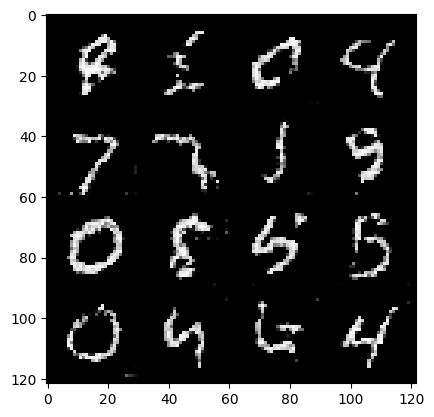

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :11, D_loss : 0.6208, G_loss : 0.9279


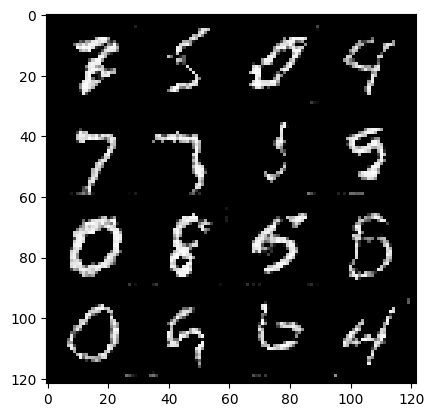

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :12, D_loss : 0.6094, G_loss : 0.9574


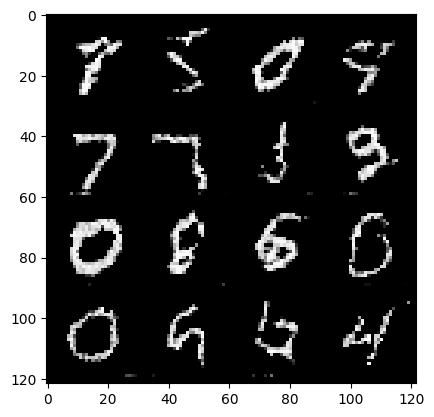

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :13, D_loss : 0.5977, G_loss : 0.9866


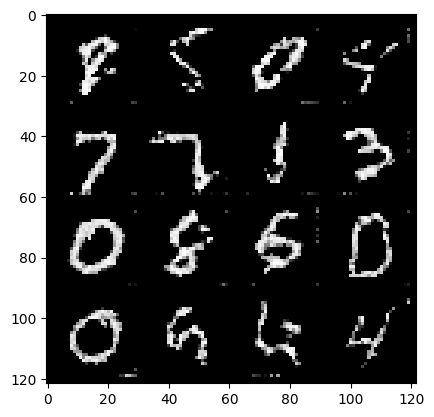

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :14, D_loss : 0.5871, G_loss : 1.0224


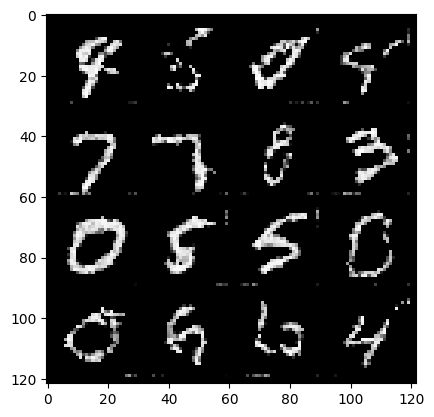

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :15, D_loss : 0.5806, G_loss : 1.0503


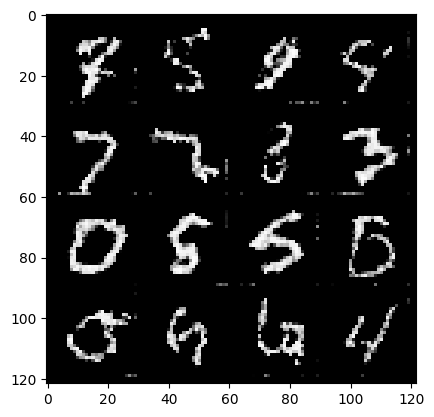

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :16, D_loss : 0.5745, G_loss : 1.0685


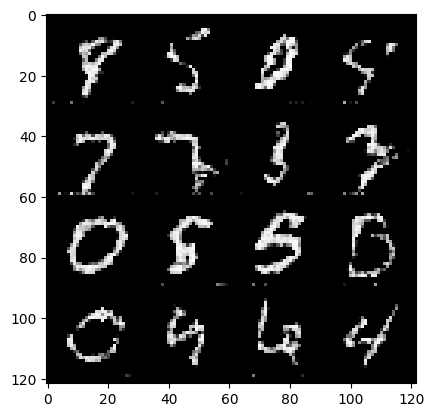

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :17, D_loss : 0.5719, G_loss : 1.0871


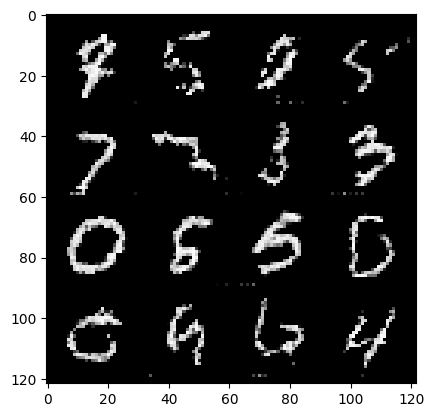

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :18, D_loss : 0.5650, G_loss : 1.1008


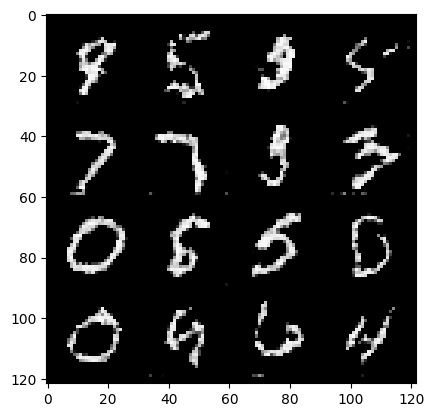

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :19, D_loss : 0.5641, G_loss : 1.1079


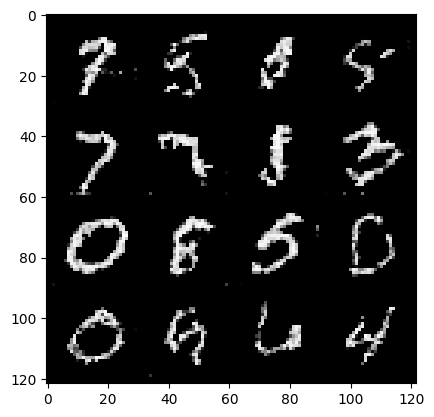

  0%|          | 0/469 [00:00<?, ?it/s]

Epoch :20, D_loss : 0.5610, G_loss : 1.1197


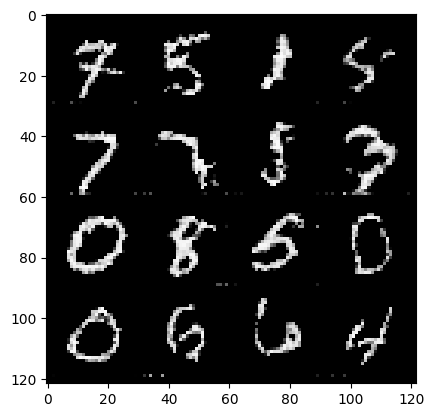

In [ ]:
fixed_noise_for_display = torch.randn(16, noise_dim, device=device)

for i in range(epochs):
  total_D_loss = 0
  total_G_loss = 0

  for real_images, _ in tqdm(trainloader):
    curr_batch_size = real_images.shape[0]
    real_image = real_images.to(device)

    # ===============================================
    # Train Discriminator
    # ===============================================
    D_opt.zero_grad()

    # Generate fake images and detach them from the generator's graph
    noise = torch.randn(curr_batch_size, noise_dim, device=device)
    fake_images = G(noise).detach()

    # Calculate discriminator loss on fake images
    D_pred_fake = D(fake_images)
    D_fake_loss = fake_loss(D_pred_fake)

    # Calculate discriminator loss on real images
    D_pred_real = D(real_image)
    D_real_loss = real_loss(D_pred_real)

    # Combine and update discriminator
    D_loss = (D_fake_loss + D_real_loss) / 2
    D_loss.backward()
    D_opt.step()

    total_D_loss += D_loss.item()

    # ===============================================
    # Train Generator
    # ===============================================
    G_opt.zero_grad()

    # Generate new fake images for generator training (gradients enabled for G)
    noise = torch.randn(curr_batch_size, noise_dim, device=device)
    fake_images_for_G = G(noise)

    # Calculate generator loss (G wants D to predict 'real' for fake images)
    D_pred_for_G = D(fake_images_for_G)
    G_loss = real_loss(D_pred_for_G)

    # Update generator
    G_loss.backward()
    G_opt.step()

    total_G_loss += G_loss.item()

  # Calculate average losses for the epoch
  avg_d_loss = total_D_loss / len(trainloader)
  avg_g_loss = total_G_loss / len(trainloader)

  print('Epoch :{}, D_loss : {:.4f}, G_loss : {:.4f}'.format(i + 1, avg_d_loss, avg_g_loss))

  # Show generated images for this epoch using a fixed noise vector
  with torch.no_grad():
      generated_images_for_display = G(fixed_noise_for_display)
  show_tensor_images(generated_images_for_display, num_images=16)


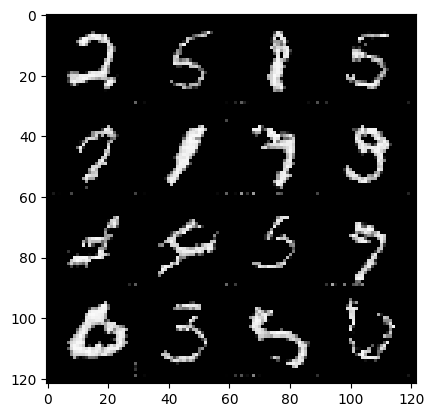

In [ ]:
# Run after training is completed.
# Now you can use Generator Network to generate handwritten images

noise = torch.randn(batch_size, noise_dim, device = device)
generated_image = G(noise)

show_tensor_images(generated_image)

# For updates about upcoming and current guided projects follow me on...

Twitter : @parth_AI

Linkedin : www.linkedin.com/in/pdhameliya